# IPL EDA & Visualisations
Runs `datacleaning.ipynb` to load cleaned `matches` and `deliveries` dataframes, then produces plots.

In [6]:
import pandas as pd

BASE_PATH = r'C:\Users\harsh\OneDrive\Desktop\ipl data analysis\datanew'
matches = pd.read_csv(rf'{BASE_PATH}\matches_clean.csv', parse_dates=['match_date'])
deliveries = pd.read_csv(rf'{BASE_PATH}\deliveries_clean.csv')

import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('plots', exist_ok=True)

In [8]:
print(matches[matches['team1'].str.contains('Deccan', na=False)].shape)
print(matches[matches['match_winner'].str.contains('Deccan', na=False)].shape)
print(matches[matches['team1'].str.contains('Deccan', na=False)]['match_winner'].value_counts())

(0, 23)
(0, 23)
Series([], Name: count, dtype: int64)


## Cell 2 — Team colors
Print exact team names from the cleaned data and define `team_colors` against those exact strings.

In [2]:
print(matches['team1'].unique())

team_colors = {
    'Chennai Super Kings':         '#FFFF3C',
    'Mumbai Indians':              '#004B8D',
    'Royal Challengers Bangalore': '#DA1818',
    'Kolkata Knight Riders':       '#3A225D',
    'Rajasthan Royals':            '#EA1A85',
    'Sunrisers Hyderabad':         '#E04F16',
    'Delhi Capitals':              '#17449B',
    'Punjab Kings':                '#DD1F2D',
    'Gujarat Titans':              '#0B214C',
    'Lucknow Super Giants':        '#0057E2',
    'Rising Pune Supergiants':     '#B7387C',
    'Gujarat Lions':               '#F7A721',
    'Kochi Tuskers Kerala':        '#502D7F',
    'Deccan Chargers':             '#6B7280',
    'Pune Warriors':               '#3F8DCC',
}
default_color = '#888888'

['Royal Challengers Bangalore' 'Sunrisers Hyderabad'
 'Rising Pune Supergiants' 'Gujarat Lions' 'Punjab Kings' 'Mumbai Indians'
 'Kolkata Knight Riders' 'Delhi Capitals' 'Rajasthan Royals'
 'Chennai Super Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Kochi Tuskers Kerala' 'Pune Warriors']


## Cell 3 — Compute win percentages
Drop NA winners and exclude 2026 (incomplete season).

In [3]:
m = matches[(matches['match_winner'].notna()) & (matches['season'] != 2026)]
total_played = m['team1'].value_counts().add(m['team2'].value_counts(), fill_value=0)
total_wins = m['match_winner'].value_counts()
win_pct = (total_wins / total_played * 100).round(2).sort_values(ascending=False)
print(win_pct)

Gujarat Titans                 61.67
Chennai Super Kings            56.75
Mumbai Indians                 55.23
Lucknow Super Giants           51.72
Kolkata Knight Riders          51.52
Rajasthan Royals               50.64
Rising Pune Supergiants        50.00
Royal Challengers Bangalore    49.26
Punjab Kings                   46.59
Sunrisers Hyderabad            46.49
Delhi Capitals                 45.69
Gujarat Lions                  43.33
Kochi Tuskers Kerala           42.86
Pune Warriors                  28.26
Name: count, dtype: float64


## Cell 4 — Plot 1: Team Win % (horizontal bar)

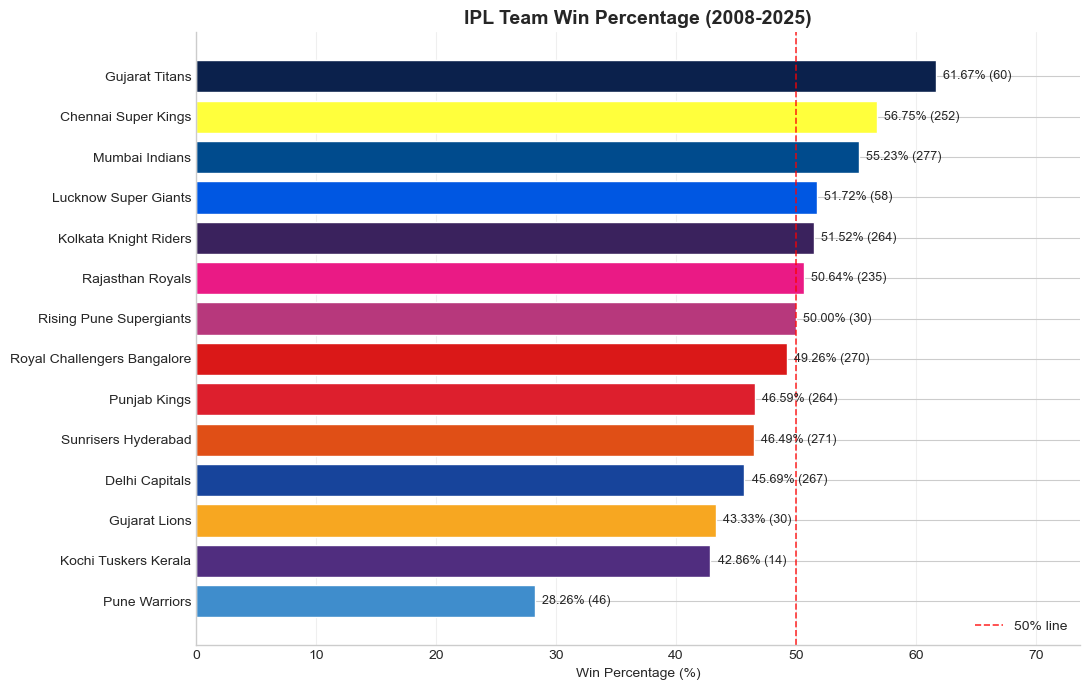

In [4]:
win_pct_asc = win_pct.sort_values(ascending=True)
bar_colors = [team_colors.get(t, default_color) for t in win_pct_asc.index]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(win_pct_asc.index, win_pct_asc.values, color=bar_colors, edgecolor='white')

ax.axvline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label='50% line')

for bar, team in zip(bars, win_pct_asc.index):
    pct = bar.get_width()
    played = int(total_played[team])
    ax.text(pct + 0.6, bar.get_y() + bar.get_height() / 2,
            f'{pct:.2f}% ({played})',
            va='center', ha='left', fontsize=9)

ax.set_xlabel('Win Percentage (%)')
ax.set_title('IPL Team Win Percentage (2008-2025)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(win_pct_asc.values) + 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('plots/01_team_win_pct.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Plot 2: Toss Analysis (3 subplots)

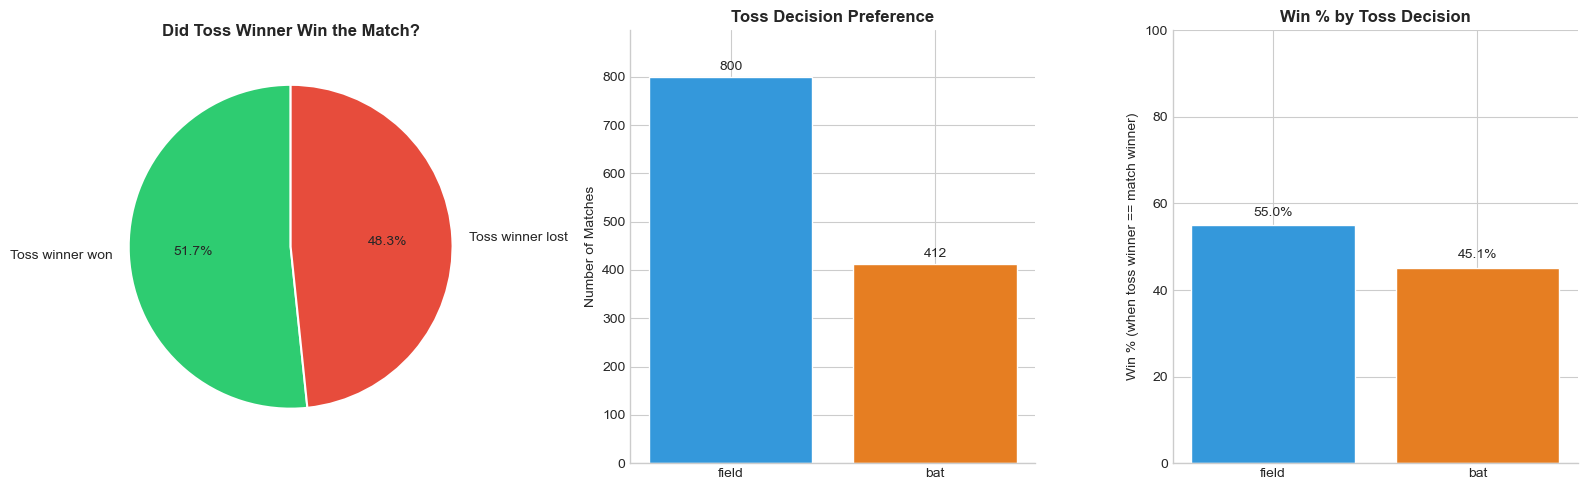

In [5]:
toss_m = matches[matches['match_winner'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: did toss winner also win the match?
won = (toss_m['toss_winner'] == toss_m['match_winner']).sum()
lost = (toss_m['toss_winner'] != toss_m['match_winner']).sum()
axes[0].pie([won, lost],
            labels=['Toss winner won', 'Toss winner lost'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Did Toss Winner Win the Match?', fontsize=12, fontweight='bold')

# Subplot 2: bat vs field preference
decision_counts = matches['toss_decision'].value_counts()
bars2 = axes[1].bar(decision_counts.index, decision_counts.values,
                    color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Toss Decision Preference', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Matches')
axes[1].set_ylim(0, max(decision_counts.values) * 1.12)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h + 8,
                 f'{int(h)}', ha='center', va='bottom', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Subplot 3: win % conditioned on toss decision (numerator restricted to toss_winner == match_winner)
total_by_decision = toss_m['toss_decision'].value_counts()
won_by_decision = toss_m[toss_m['toss_winner'] == toss_m['match_winner']]['toss_decision'].value_counts()
pct_by_decision = (won_by_decision / total_by_decision * 100).round(2)
pct_by_decision = pct_by_decision.reindex(decision_counts.index)
bars3 = axes[2].bar(pct_by_decision.index, pct_by_decision.values,
                    color=['#3498db', '#e67e22'], edgecolor='white')
axes[2].set_title('Win % by Toss Decision', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Win % (when toss winner == match winner)')
axes[2].set_ylim(0, 100)
for bar in bars3:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, h + 1.5,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=10)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/02_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Captain dictionary: {(team, season): captain_name}
captains = {
    ('Chennai Super Kings', 2008): 'MS Dhoni',
    ('Chennai Super Kings', 2009): 'MS Dhoni',
    ('Chennai Super Kings', 2010): 'MS Dhoni',
    ('Chennai Super Kings', 2011): 'MS Dhoni',
    ('Chennai Super Kings', 2012): 'MS Dhoni',
    ('Chennai Super Kings', 2013): 'MS Dhoni',
    ('Chennai Super Kings', 2014): 'MS Dhoni',
    ('Chennai Super Kings', 2015): 'MS Dhoni',
    ('Chennai Super Kings', 2018): 'MS Dhoni',
    ('Chennai Super Kings', 2019): 'MS Dhoni',
    ('Chennai Super Kings', 2021): 'MS Dhoni',
    ('Chennai Super Kings', 2022): 'MS Dhoni',
    ('Chennai Super Kings', 2023): 'MS Dhoni',
    ('Chennai Super Kings', 2024): 'Ruturaj Gaikwad',
    ('Chennai Super Kings', 2025): 'Ruturaj Gaikwad',

    ('Mumbai Indians', 2008): 'Sachin Tendulkar',
    ('Mumbai Indians', 2009): 'Sachin Tendulkar',
    ('Mumbai Indians', 2010): 'Sachin Tendulkar',
    ('Mumbai Indians', 2011): 'Harbhajan Singh',
    ('Mumbai Indians', 2012): 'Rohit Sharma',
    ('Mumbai Indians', 2013): 'Rohit Sharma',
    ('Mumbai Indians', 2014): 'Rohit Sharma',
    ('Mumbai Indians', 2015): 'Rohit Sharma',
    ('Mumbai Indians', 2016): 'Rohit Sharma',
    ('Mumbai Indians', 2017): 'Rohit Sharma',
    ('Mumbai Indians', 2018): 'Rohit Sharma',
    ('Mumbai Indians', 2019): 'Rohit Sharma',
    ('Mumbai Indians', 2021): 'Rohit Sharma',
    ('Mumbai Indians', 2022): 'Rohit Sharma',
    ('Mumbai Indians', 2023): 'Rohit Sharma',
    ('Mumbai Indians', 2024): 'Hardik Pandya',
    ('Mumbai Indians', 2025): 'Hardik Pandya',

    ('Royal Challengers Bangalore', 2008): 'Rahul Dravid',
    ('Royal Challengers Bangalore', 2009): 'Anil Kumble',
    ('Royal Challengers Bangalore', 2010): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2011): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2012): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2013): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2014): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2015): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2016): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2017): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2018): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2019): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2021): 'Virat Kohli',
    ('Royal Challengers Bangalore', 2022): 'Faf du Plessis',
    ('Royal Challengers Bangalore', 2023): 'Faf du Plessis',
    ('Royal Challengers Bangalore', 2024): 'Faf du Plessis',
    ('Royal Challengers Bangalore', 2025): 'Rajat Patidar',

    ('Kolkata Knight Riders', 2008): 'Sourav Ganguly',
    ('Kolkata Knight Riders', 2009): 'Sourav Ganguly',
    ('Kolkata Knight Riders', 2010): 'Sourav Ganguly',
    ('Kolkata Knight Riders', 2011): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2012): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2013): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2014): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2015): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2016): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2017): 'Gautam Gambhir',
    ('Kolkata Knight Riders', 2018): 'Dinesh Karthik',
    ('Kolkata Knight Riders', 2019): 'Dinesh Karthik',
    ('Kolkata Knight Riders', 2021): 'Eoin Morgan',
    ('Kolkata Knight Riders', 2022): 'Shreyas Iyer',
    ('Kolkata Knight Riders', 2023): 'Nitish Rana',
    ('Kolkata Knight Riders', 2024): 'Shreyas Iyer',
    ('Kolkata Knight Riders', 2025): 'Ajinkya Rahane',

    ('Rajasthan Royals', 2008): 'Shane Warne',
    ('Rajasthan Royals', 2009): 'Shane Warne',
    ('Rajasthan Royals', 2010): 'Shane Warne',
    ('Rajasthan Royals', 2011): 'Rahul Dravid',
    ('Rajasthan Royals', 2012): 'Rahul Dravid',
    ('Rajasthan Royals', 2013): 'Rahul Dravid',
    ('Rajasthan Royals', 2014): 'Rahul Dravid',
    ('Rajasthan Royals', 2015): 'Steven Smith',
    ('Rajasthan Royals', 2018): 'Ajinkya Rahane',
    ('Rajasthan Royals', 2019): 'Ajinkya Rahane',
    ('Rajasthan Royals', 2021): 'Sanju Samson',
    ('Rajasthan Royals', 2022): 'Sanju Samson',
    ('Rajasthan Royals', 2023): 'Sanju Samson',
    ('Rajasthan Royals', 2024): 'Sanju Samson',
    ('Rajasthan Royals', 2025): 'Sanju Samson',

    ('Sunrisers Hyderabad', 2013): 'Kumar Sangakkara',
    ('Sunrisers Hyderabad', 2014): 'Darren Sammy',
    ('Sunrisers Hyderabad', 2015): 'David Warner',
    ('Sunrisers Hyderabad', 2016): 'David Warner',
    ('Sunrisers Hyderabad', 2017): 'David Warner',
    ('Sunrisers Hyderabad', 2018): 'Kane Williamson',
    ('Sunrisers Hyderabad', 2019): 'David Warner',
    ('Sunrisers Hyderabad', 2021): 'David Warner',
    ('Sunrisers Hyderabad', 2022): 'Kane Williamson',
    ('Sunrisers Hyderabad', 2023): 'Aiden Markram',
    ('Sunrisers Hyderabad', 2024): 'Pat Cummins',
    ('Sunrisers Hyderabad', 2025): 'Pat Cummins',

    ('Delhi Capitals', 2008): 'Virender Sehwag',
    ('Delhi Capitals', 2009): 'Virender Sehwag',
    ('Delhi Capitals', 2010): 'Virender Sehwag',
    ('Delhi Capitals', 2011): 'Virender Sehwag',
    ('Delhi Capitals', 2012): 'Virender Sehwag',
    ('Delhi Capitals', 2013): 'Virender Sehwag',
    ('Delhi Capitals', 2014): 'Virender Sehwag',
    ('Delhi Capitals', 2015): 'JP Duminy',
    ('Delhi Capitals', 2016): 'Zaheer Khan',
    ('Delhi Capitals', 2017): 'Zaheer Khan',
    ('Delhi Capitals', 2018): 'Shreyas Iyer',
    ('Delhi Capitals', 2019): 'Shreyas Iyer',
    ('Delhi Capitals', 2021): 'Rishabh Pant',
    ('Delhi Capitals', 2022): 'Rishabh Pant',
    ('Delhi Capitals', 2023): 'David Warner',
    ('Delhi Capitals', 2024): 'Rishabh Pant',
    ('Delhi Capitals', 2025): 'KL Rahul',

    ('Punjab Kings', 2008): 'Yuvraj Singh',
    ('Punjab Kings', 2009): 'Yuvraj Singh',
    ('Punjab Kings', 2010): 'Kumar Sangakkara',
    ('Punjab Kings', 2011): 'Adam Gilchrist',
    ('Punjab Kings', 2012): 'Adam Gilchrist',
    ('Punjab Kings', 2013): 'Adam Gilchrist',
    ('Punjab Kings', 2014): 'George Bailey',
    ('Punjab Kings', 2015): 'George Bailey',
    ('Punjab Kings', 2016): 'Murali Vijay',
    ('Punjab Kings', 2017): 'Glenn Maxwell',
    ('Punjab Kings', 2018): 'Ravichandran Ashwin',
    ('Punjab Kings', 2019): 'Ravichandran Ashwin',
    ('Punjab Kings', 2021): 'KL Rahul',
    ('Punjab Kings', 2022): 'Mayank Agarwal',
    ('Punjab Kings', 2023): 'Shikhar Dhawan',
    ('Punjab Kings', 2024): 'Shikhar Dhawan',
    ('Punjab Kings', 2025): 'Shreyas Iyer',

    ('Gujarat Titans', 2022): 'Hardik Pandya',
    ('Gujarat Titans', 2023): 'Hardik Pandya',
    ('Gujarat Titans', 2024): 'Shubman Gill',
    ('Gujarat Titans', 2025): 'Shubman Gill',

    ('Lucknow Super Giants', 2022): 'KL Rahul',
    ('Lucknow Super Giants', 2023): 'KL Rahul',
    ('Lucknow Super Giants', 2024): 'KL Rahul',
    ('Lucknow Super Giants', 2025): 'Rishabh Pant',

    ('Rising Pune Supergiants', 2016): 'MS Dhoni',
    ('Rising Pune Supergiants', 2017): 'Steve Smith',

    ('Gujarat Lions', 2016): 'Suresh Raina',
    ('Gujarat Lions', 2017): 'Suresh Raina',

    ('Pune Warriors', 2011): 'Sourav Ganguly',
    ('Pune Warriors', 2012): 'Sourav Ganguly',
    ('Pune Warriors', 2013): 'Aaron Finch',

    ('Kochi Tuskers Kerala', 2011): 'Mahela Jayawardene',
}

m = m.copy()  # add this line before the two apply lines
# Map captain to each match for both teams
m['team1_captain'] = m.apply(lambda x: captains.get((x['team1'], x['season']), 'Unknown'), axis=1)
m['team2_captain'] = m.apply(lambda x: captains.get((x['team2'], x['season']), 'Unknown'), axis=1)

# Build toss records per captain
records = []
for _, row in m.iterrows():
    for team, captain in [('team1', 'team1_captain'), ('team2', 'team2_captain')]:
        records.append({
            'captain': row[captain],
            'toss_won': row['toss_winner'] == row[team],
        })

toss_captain = pd.DataFrame(records)
toss_captain = toss_captain[toss_captain['captain'] != 'Unknown']

# Calculate toss win % and matches
captain_stats = toss_captain.groupby('captain').agg(
    toss_wins=('toss_won', 'sum'),
    total=('toss_won', 'count')
).reset_index()
captain_stats['toss_win_pct'] = (captain_stats['toss_wins'] / captain_stats['total'] * 100).round(2)

# Only captains with 20+ matches to avoid small sample noise
captain_stats = captain_stats[captain_stats['total'] >= 20].sort_values('toss_win_pct', ascending=True)

captain_stats_sorted = captain_stats.sort_values('toss_wins', ascending=False).reset_index(drop=True)
print(captain_stats_sorted)

                captain  toss_wins  total  toss_win_pct
0              MS Dhoni        126    238         52.94
1          Rohit Sharma        104    188         55.32
2           Virat Kohli         84    180         46.67
3        Gautam Gambhir         58    108         53.70
4       Virender Sehwag         51    105         48.57
5          David Warner         50    104         48.08
6          Sanju Samson         47     88         53.41
7          Shreyas Iyer         42     76         55.26
8          Rahul Dravid         41     75         54.67
9          Rishabh Pant         38     75         50.67
10        Hardik Pandya         37     63         58.73
11             KL Rahul         36     87         41.38
12       Sourav Ganguly         31     70         44.29
13       Adam Gilchrist         25     46         54.35
14       Faf du Plessis         24     45         53.33
15     Sachin Tendulkar         23     43         53.49
16       Ajinkya Rahane         23     42       

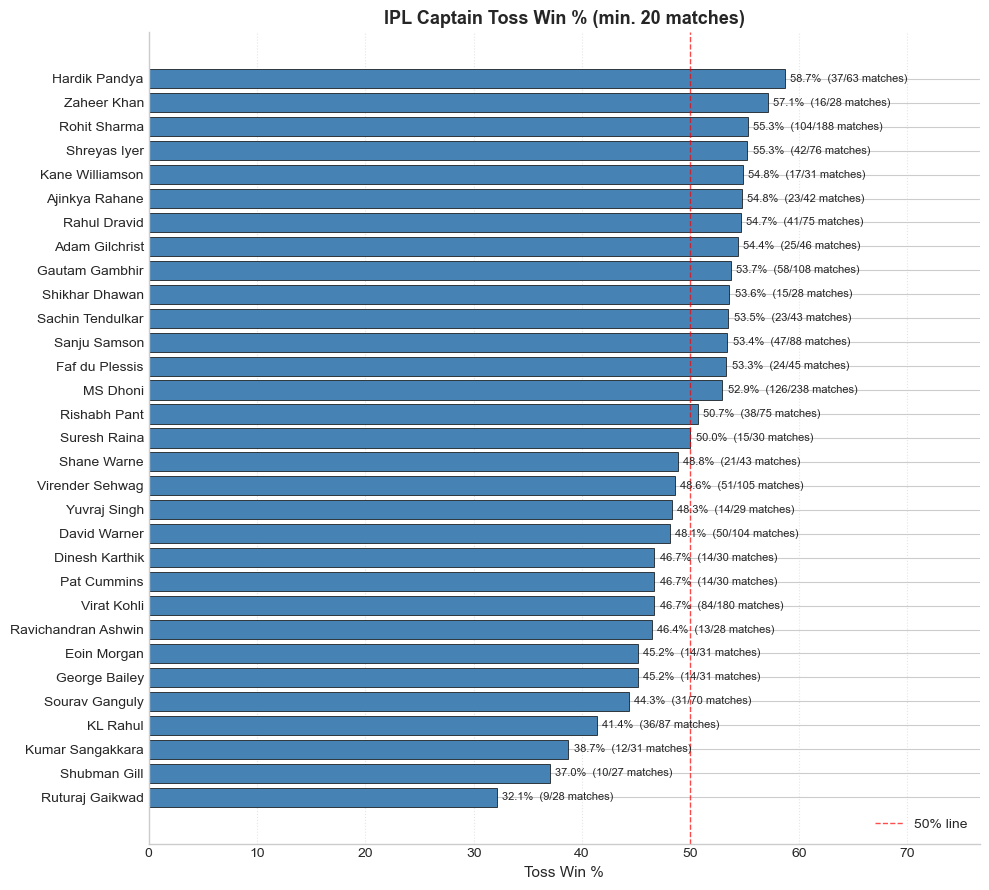

In [18]:
fig, ax = plt.subplots(figsize=(10, 9))

plot_data = captain_stats.sort_values('toss_win_pct', ascending=True).reset_index(drop=True)

bars = ax.barh(plot_data['captain'], plot_data['toss_win_pct'], color='steelblue', edgecolor='black', linewidth=0.5)

ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% line')

for bar, wins, total in zip(bars, plot_data['toss_wins'], plot_data['total']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%  ({wins}/{total} matches)",
            va='center', ha='left', fontsize=8)

ax.set_xlim(0, plot_data['toss_win_pct'].max() + 18)
ax.set_xlabel('Toss Win %', fontsize=11)
ax.set_title('IPL Captain Toss Win % (min. 20 matches)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('plots/03_captain_toss.png', dpi=150)
plt.show()

In [19]:
top_batters = (deliveries[deliveries['is_wide_ball'] == False]
               .groupby('batter')['batter_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10))

print(top_batters)

batter
V Kohli           9050
RG Sharma         7185
S Dhawan          6769
DA Warner         6567
KL Rahul          5668
SK Raina          5536
MS Dhoni          5439
AM Rahane         5194
AB de Villiers    5181
SV Samson         5008
Name: batter_runs, dtype: int64


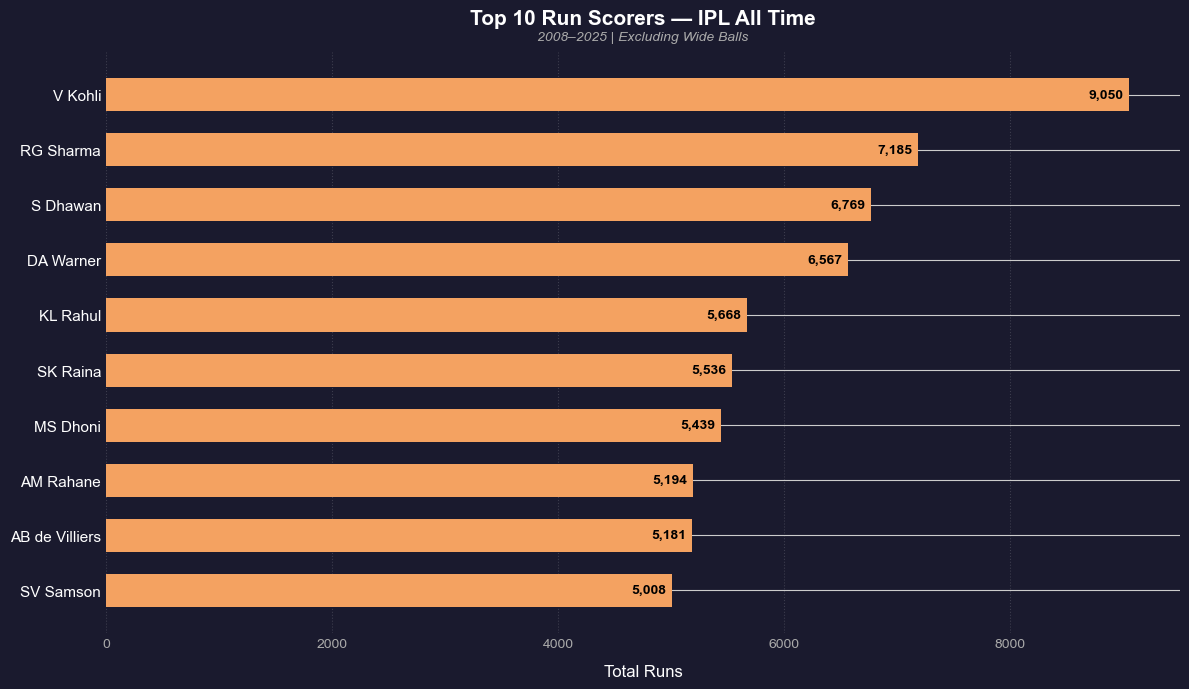

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

top_batters = (deliveries[deliveries['is_wide_ball'] == False]
               .groupby('batter')['batter_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .sort_values(ascending=True))

bars = ax.barh(top_batters.index, top_batters.values,
               color='#f4a261', edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() - 50, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}",
            va='center', ha='right', fontsize=10,
            color='black', fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=12, color='white', labelpad=10)
ax.set_title('Top 10 Run Scorers — IPL All Time',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, '2008–2025 | Excluding Wide Balls',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.tick_params(axis='y', colors='white', labelsize=11)
ax.tick_params(axis='x', colors='#aaaaaa', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('plots/04_top_batters.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

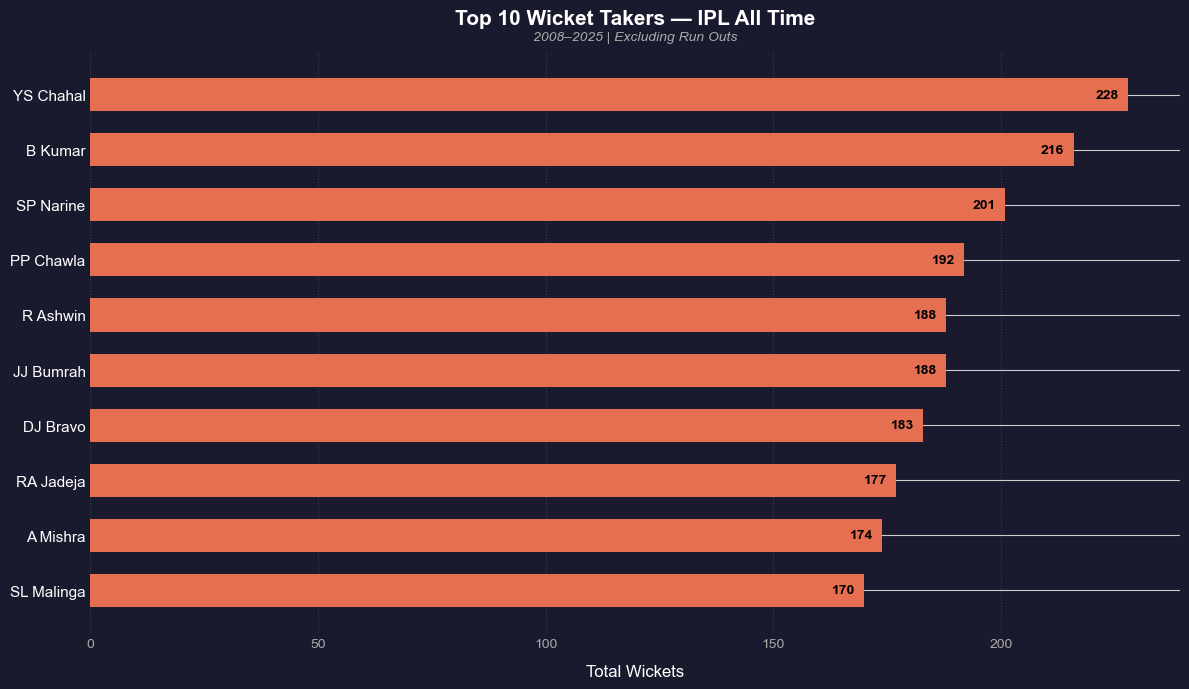

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

top_bowlers = (deliveries[(deliveries['is_wicket'] == True) & 
                          (deliveries['wicket_kind'] != 'run out')]
               .groupby('bowler')['is_wicket']
               .count()
               .sort_values(ascending=False)
               .head(10)
               .sort_values(ascending=True))

bars = ax.barh(top_bowlers.index, top_bowlers.values,
               color='#e76f51', edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}",
            va='center', ha='right', fontsize=10,
            color='black', fontweight='bold')

ax.set_xlabel('Total Wickets', fontsize=12, color='white', labelpad=10)
ax.set_title('Top 10 Wicket Takers — IPL All Time',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, '2008–2025 | Excluding Run Outs',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.tick_params(axis='y', colors='white', labelsize=11)
ax.tick_params(axis='x', colors='#aaaaaa', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('plots/05_top_bowlers.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

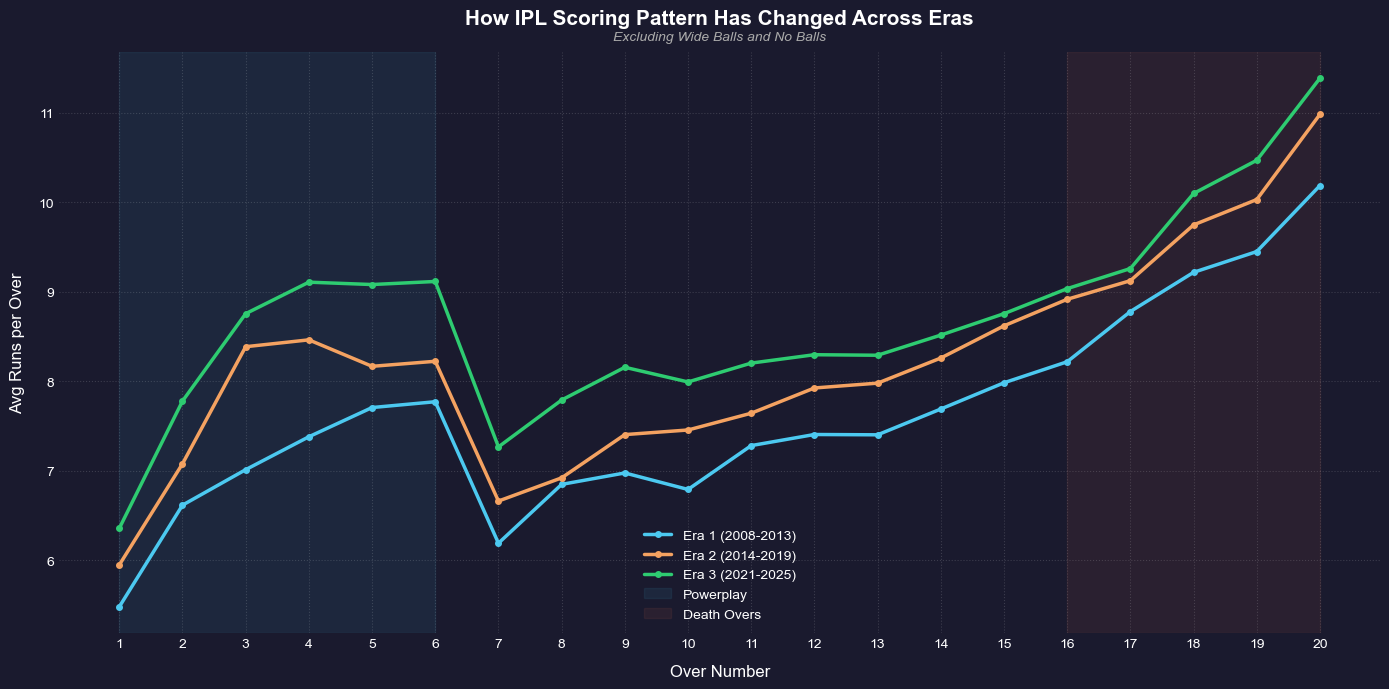

In [ ]:
# Create era column
def get_era(season):
    if season <= 2013:
        return 'Era 1 (2008-2013)'
    elif season <= 2019:
        return 'Era 2 (2014-2019)'
    else:
        return 'Era 3 (2021-2025)'

deliveries['era'] = deliveries['season_id'].apply(get_era)

# Average runs per over per era (exclude wides and no balls)
era_over = (deliveries[(deliveries['is_wide_ball'] == False) & 
                       (deliveries['is_no_ball'] == False)]
            .groupby(['era', 'over_number'])['total_runs']
            .mean()
            .reset_index())

era_over['runs_per_over'] = era_over['total_runs'] * 6

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

era_colors = {
    'Era 1 (2008-2013)': '#4cc9f0',
    'Era 2 (2014-2019)': '#f4a261',
    'Era 3 (2021-2025)': '#2ecc71'
}

for era, grp in era_over.groupby('era'):
    ax.plot(grp['over_number'] + 1, grp['runs_per_over'],
            label=era, color=era_colors[era],
            linewidth=2.5, marker='o', markersize=4)

ax.axvspan(1, 6, alpha=0.08, color='#4cc9f0', label='Powerplay')
ax.axvspan(16, 20, alpha=0.08, color='#e76f51', label='Death Overs')

ax.set_xlabel('Over Number', fontsize=12, color='white', labelpad=10)
ax.set_ylabel('Avg Runs per Over', fontsize=12, color='white', labelpad=10)
ax.set_title('How IPL Scoring Pattern Has Changed Across Eras',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, 'Excluding Wide Balls and No Balls',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.set_xticks(range(1, 21))
ax.tick_params(axis='both', colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(linestyle=':', alpha=0.15, color='white')
ax.legend(frameon=False, labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('plots/06_scoring_pattern_era.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show() 

Total 4s all time: 32,113
Total 6s all time: 14,353


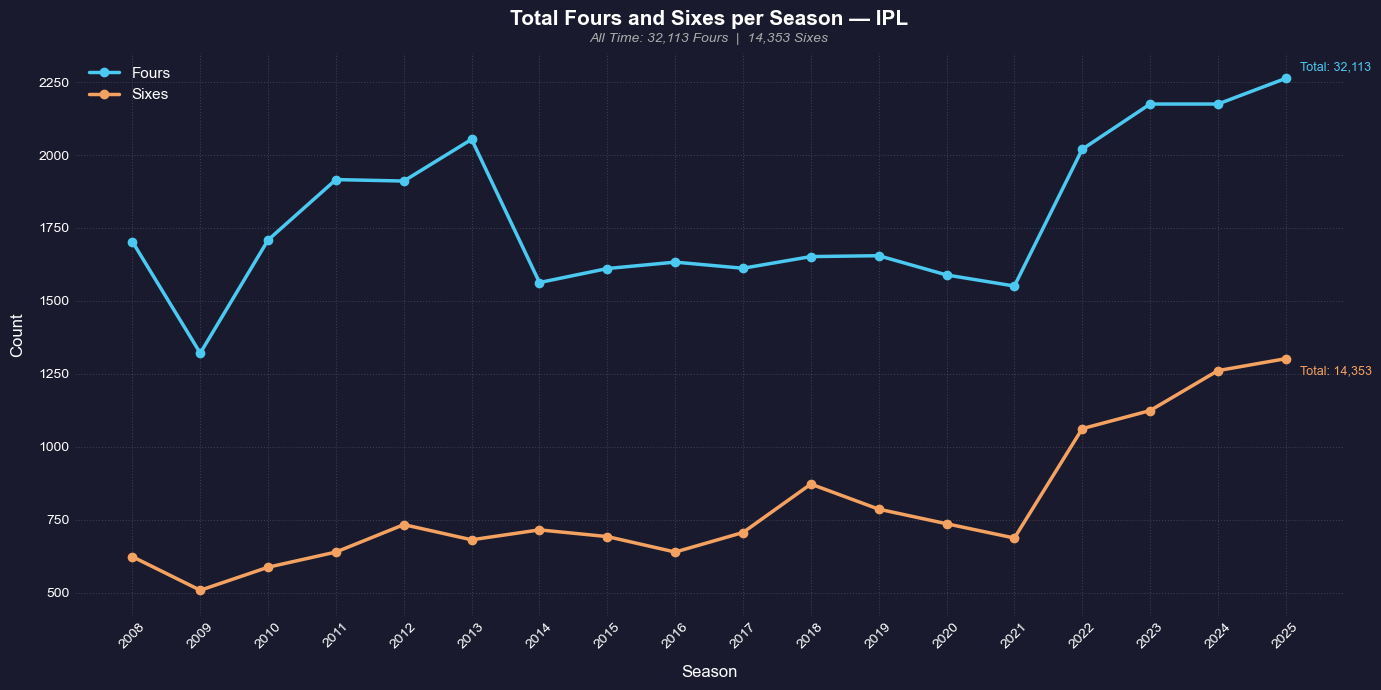

In [26]:
# 4s and 6s per season
fours_sixes = (deliveries[deliveries['is_wide_ball'] == False]
               .groupby('season_id')
               .agg(
                   fours=('batter_runs', lambda x: (x == 4).sum()),
                   sixes=('batter_runs', lambda x: (x == 6).sum())
               )
               .reset_index()
               .query('season_id != 2026'))

# Overall totals
total_fours = fours_sixes['fours'].sum()
total_sixes = fours_sixes['sixes'].sum()
print(f"Total 4s all time: {total_fours:,}")
print(f"Total 6s all time: {total_sixes:,}")

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.plot(fours_sixes['season_id'], fours_sixes['fours'],
        color='#4cc9f0', linewidth=2.5, marker='o', markersize=6, label='Fours')
ax.plot(fours_sixes['season_id'], fours_sixes['sixes'],
        color='#f4a261', linewidth=2.5, marker='o', markersize=6, label='Sixes')

# Annotate last point with overall total
ax.annotate(f'Total: {total_fours:,}',
            xy=(fours_sixes['season_id'].iloc[-1], fours_sixes['fours'].iloc[-1]),
            xytext=(10, 5), textcoords='offset points',
            color='#4cc9f0', fontsize=9)
ax.annotate(f'Total: {total_sixes:,}',
            xy=(fours_sixes['season_id'].iloc[-1], fours_sixes['sixes'].iloc[-1]),
            xytext=(10, -12), textcoords='offset points',
            color='#f4a261', fontsize=9)

ax.set_xlabel('Season', fontsize=12, color='white', labelpad=10)
ax.set_ylabel('Count', fontsize=12, color='white', labelpad=10)
ax.set_title('Total Fours and Sixes per Season — IPL',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, f'All Time: {total_fours:,} Fours  |  {total_sixes:,} Sixes',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.set_xticks(fours_sixes['season_id'])
ax.tick_params(axis='both', colors='white', labelsize=10)
plt.xticks(rotation=45)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(linestyle=':', alpha=0.15, color='white')
ax.legend(frameon=False, labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('plots/07_fours_sixes_per_season.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

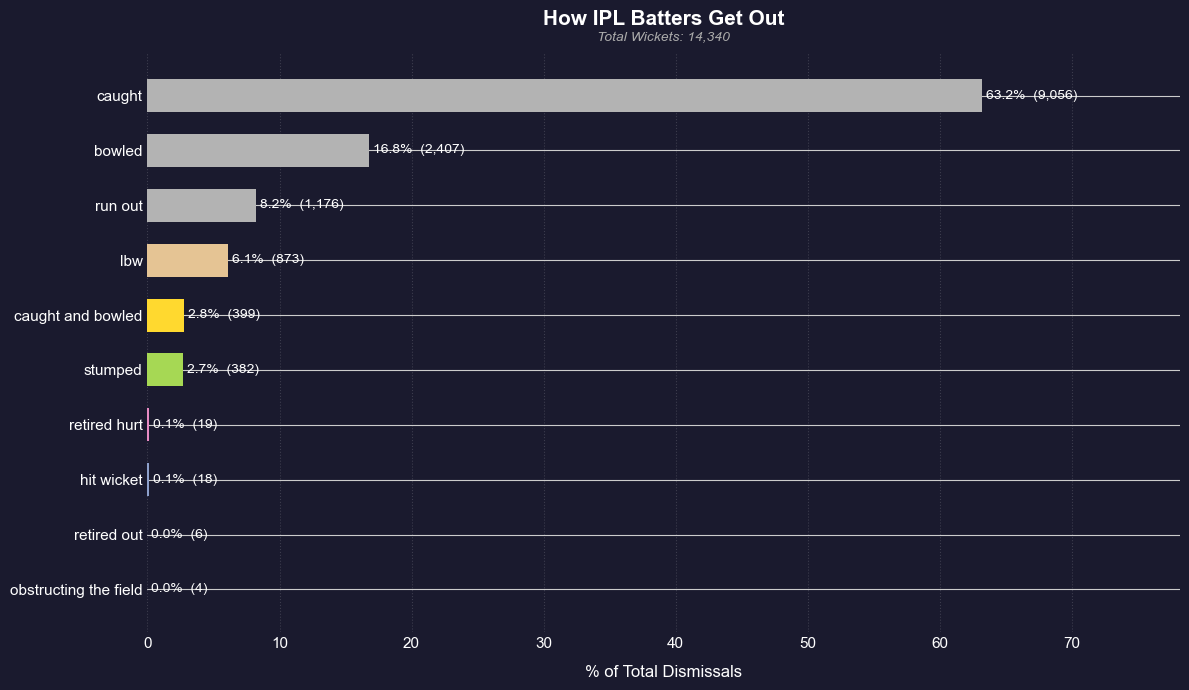

In [28]:
dismissals = (deliveries[deliveries['is_wicket'] == True]
              .groupby('wicket_kind')['is_wicket']
              .count()
              .sort_values(ascending=True)
              .reset_index())
dismissals.columns = ['wicket_kind', 'count']
dismissals['pct'] = (dismissals['count'] / dismissals['count'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

colors = plt.cm.Set2(range(len(dismissals)))
bars = ax.barh(dismissals['wicket_kind'], dismissals['pct'],
               color=colors, edgecolor='none', height=0.6)

for bar, count, pct in zip(bars, dismissals['count'], dismissals['pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct}%  ({count:,})",
            va='center', ha='left', fontsize=10, color='white')

ax.set_xlim(0, dismissals['pct'].max() + 15)
ax.set_xlabel('% of Total Dismissals', fontsize=12, color='white', labelpad=10)
ax.set_title('How IPL Batters Get Out',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, f"Total Wickets: {dismissals['count'].sum():,}",
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.tick_params(colors='white', labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('plots/08_dismissal_types.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

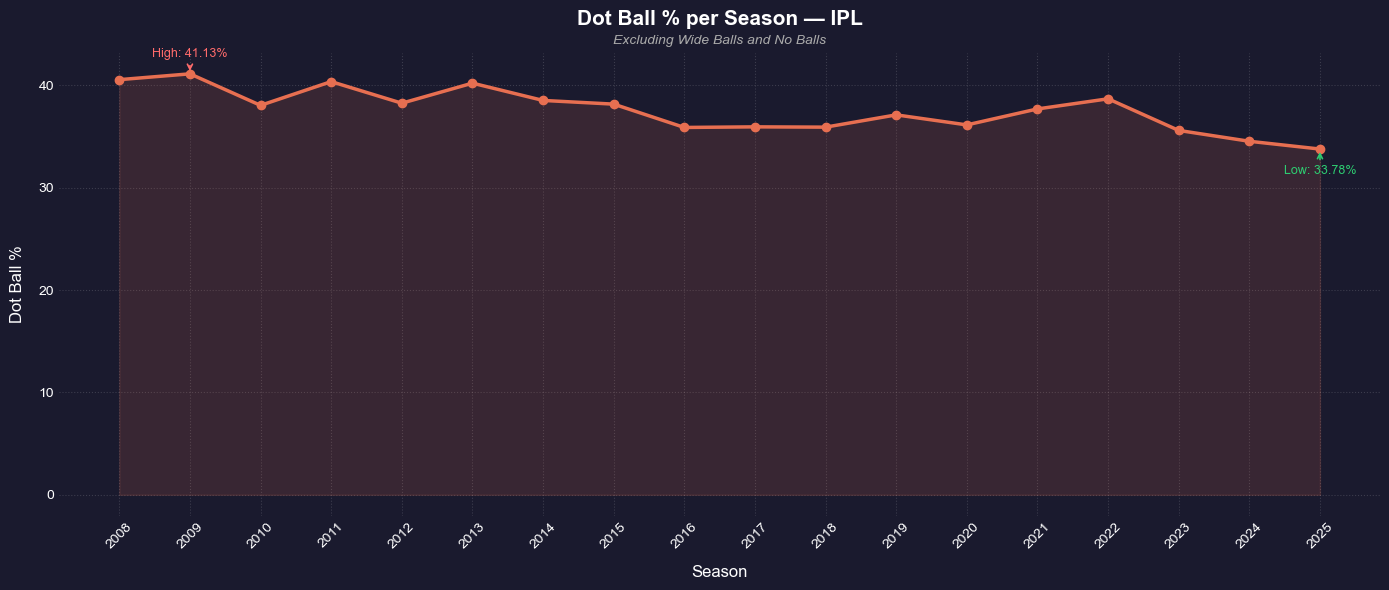

In [29]:
# Dot ball % per season
dot_balls = (deliveries[(deliveries['is_wide_ball'] == False) &
                        (deliveries['is_no_ball'] == False) &
                        (deliveries['season_id'] != 2026)]
             .groupby('season_id')
             .agg(
                 total_balls=('batter_runs', 'count'),
                 dot_balls=('batter_runs', lambda x: (x == 0).sum())
             )
             .reset_index())

dot_balls['dot_pct'] = (dot_balls['dot_balls'] / dot_balls['total_balls'] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.plot(dot_balls['season_id'], dot_balls['dot_pct'],
        color='#e76f51', linewidth=2.5, marker='o', markersize=6)

# Fill under line
ax.fill_between(dot_balls['season_id'], dot_balls['dot_pct'],
                alpha=0.15, color='#e76f51')

# Annotate min and max
max_row = dot_balls.loc[dot_balls['dot_pct'].idxmax()]
min_row = dot_balls.loc[dot_balls['dot_pct'].idxmin()]

ax.annotate(f"High: {max_row['dot_pct']}%",
            xy=(max_row['season_id'], max_row['dot_pct']),
            xytext=(0, 12), textcoords='offset points',
            ha='center', color='#ff6b6b', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#ff6b6b', lw=1.2))

ax.annotate(f"Low: {min_row['dot_pct']}%",
            xy=(min_row['season_id'], min_row['dot_pct']),
            xytext=(0, -18), textcoords='offset points',
            ha='center', color='#2ecc71', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.2))

ax.set_xlabel('Season', fontsize=12, color='white', labelpad=10)
ax.set_ylabel('Dot Ball %', fontsize=12, color='white', labelpad=10)
ax.set_title('Dot Ball % per Season — IPL',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.text(0.5, 1.02, 'Excluding Wide Balls and No Balls',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#aaaaaa', style='italic')

ax.set_xticks(dot_balls['season_id'])
plt.xticks(rotation=45)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(linestyle=':', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('plots/09_dot_ball_pct.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

In [31]:
finals = (matches.sort_values('match_number', ascending=False)
          .groupby('season')
          .first()
          .reset_index()[['season', 'match_winner']])
print(finals.sort_values('season'))

    season                 match_winner
0     2008                 Punjab Kings
1     2009  Royal Challengers Bangalore
2     2010        Kolkata Knight Riders
3     2011               Mumbai Indians
4     2012               Mumbai Indians
5     2013          Sunrisers Hyderabad
6     2014               Mumbai Indians
7     2015               Mumbai Indians
8     2016  Royal Challengers Bangalore
9     2017  Royal Challengers Bangalore
10    2018          Chennai Super Kings
11    2019               Mumbai Indians
12    2021          Sunrisers Hyderabad
13    2022                 Punjab Kings
14    2023               Gujarat Titans
15    2024          Sunrisers Hyderabad
16    2025  Royal Challengers Bangalore
17    2026               Delhi Capitals
